# 1 · det_objects — 지금 앞에 무엇이 있는가

전방 ±60° 안의 도로 사용자를 클래스와 위치로 열거합니다. 한 순간을 묻기 때문에 미래 지평선 제약이 없고, 그래서 앵커를 3/6/9/12/15/18초 여섯 곳에 둘 수 있습니다.

이 노트북은 네 가지를 확인합니다 — **어떤 원시 데이터에서**, **어떤 코드를 거쳐**, **무엇이 입력으로 들어가고**, **빌드된 파일이 그 코드와 일치하는지**. GPU 는 필요 없습니다.

In [1]:
import os, sys, json, textwrap
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))

import numpy as np
import pandas as pd

from datatools import paths

ITEMS = os.path.join(paths.COMMON_DIR, "instruct_items_tasks01_06.parquet")
pd.set_option("display.width", 170)
pd.set_option("display.max_colwidth", 80)
wrap = lambda s, i="   ": textwrap.fill(str(s), 94, initial_indent=i,
                                        subsequent_indent=i)
VARIANTS = ['det_objects_azdeg', 'det_objects_3dbbox']
print("variants:", VARIANTS)

variants: ['det_objects_azdeg', 'det_objects_3dbbox']


## 1. 어떤 원시 데이터에서 오는가

| 아카이브 | 주기 | 읽는 것 |
|---|---|---|
| `obstacle.offline` | 10 Hz | center_x/y/z, size_*, orientation_*, label_class, track_id, reference_frame='rig' |
| `egomotion` | 10 Hz | x, y, z, qx..qw — rig 좌표를 월드로 올리는 데 필요 |
| `radar (lrr1/mrr2/srr0)` | 20 또는 12.7 Hz | azimuth, elevation, distance, radial_velocity, rcs, doppler_ambiguity |
| `camera intrinsics` | 클립당 1 | f-theta 다항식 — CoT 의 카메라 방위각용 |

## 2. 어떤 코드를 거치는가

실행 순서입니다.

| 함수 | 하는 일 |
|---|---|
| `boxes_world(obstacle, ego)` | rig 좌표에서 거리·방위각, 월드 좌표에서 이동 여부 |
| `visible_at(boxes, t_s)` | ±0.15 s 창 → ±60°/300 m 섹터 → 트랙당 1관측 → 거리순 |
| `head(MAX_LISTED=8)` | 가까운 순 8개 |
| `describe_object / describe_object_xyz` | 문장화 |
| `object_evidence(scan, listed)` | CoT 용: 박스 안 반사점의 수·거리·방위각 |
| `camera_azimuth(box centre)` | CoT 용: 이미지 박스에서 역산한 방위각 |

전부 `datatools/frame_objects.py` 와 `datatools/geometry.py` 에 있습니다.

In [2]:
import inspect
from datatools import frame_objects as F
for name in ['boxes_world', 'visible_at', 'head', 'describe_object / describe_object_xyz', 'object_evidence', 'camera_azimuth']:
    fn = getattr(F, name, None)
    if fn is None:
        from datatools import geometry as G
        fn = getattr(G, name, None)
    if fn is None or not callable(fn):
        print(f'{name}: (모듈 함수 아님)'); continue
    doc = (inspect.getdoc(fn) or '').split(chr(10))[0]
    print(f'{name:34s} {doc[:80]}')

boxes_world                        Boxes with rig-frame range/azimuth and a world-frame moved flag.
visible_at                         One row per track near `t_s`, inside the forward sector, nearest first.
head: (모듈 함수 아님)
describe_object / describe_object_xyz: (모듈 함수 아님)
object_evidence                    Per-box radar evidence, geometry included: how many returns, how many
camera_azimuth                     Bearing in the rig frame, in degrees, positive left.


## 3. 입력으로 무엇이 들어가는가

**비전 1장 (질문한 순간) · 레이더 20스캔 (직전 약 1초) · ego 1샘플**

입력 창은 태스크마다 다릅니다. 로더의 `WINDOWS` 표가 그것을 정하고, 레이더는 항상 20스캔이라 창의 길이가 바뀌면 샘플링 속도가 따라 바뀝니다 — 인코더 입력 모양은 변하지 않습니다.

In [3]:
from training.instruct_data import WINDOWS, INSTANT_TASKS, WINDOW_TASKS
for v in VARIANTS:
    for name in (v, v + "_cot"):
        if name in WINDOWS:
            secs, hz, frames = WINDOWS[name]
            print(f"{name:26s} 창 {secs}초 · 레이더 {hz} Hz × 20스캔 · 비전 {frames}장")
        elif name in INSTANT_TASKS:
            print(f"{name:26s} 순간 — 비전 1장 · 레이더 20스캔/1초 · ego 1")
        else:
            print(f"{name:26s} 클립 전체 — 비전 20장 · 레이더 20스캔/20초")

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


det_objects_azdeg          순간 — 비전 1장 · 레이더 20스캔/1초 · ego 1
det_objects_azdeg_cot      순간 — 비전 1장 · 레이더 20스캔/1초 · ego 1
det_objects_3dbbox         순간 — 비전 1장 · 레이더 20스캔/1초 · ego 1
det_objects_3dbbox_cot     순간 — 비전 1장 · 레이더 20스캔/1초 · ego 1


## 4. 예제 10건 — 원시 입력째로

`notebooks/example_data/` 에 테스크마다 10건이 들어 있습니다. **parquet 도 원본 아카이브도 필요 없습니다.**

| 경로 | 내용 |
|---|---|
| `gen_data/<task>.jsonl` | LLM 학습에 쓰이는 아이템 그대로 — instruction, ego, 정답, 근거 |
| `raw/<task>/NN/frames/` | 그 아이템에 실제로 들어가는 프레임 |
| `raw/<task>/NN/radar.npz` | 그 창의 레이더 반사점 (패딩 제거) |

평문 변형과 CoT 변형은 같은 아이템입니다 — CoT 정답의 `answer` 필드가 평문 정답과 글자 그대로 같아서, 한 건이 둘을 모두 보여줍니다.

In [4]:
import glob
EX = os.path.abspath(os.path.join(os.getcwd(), "..", "example_data"))
examples = {}
for v in VARIANTS:
    path = os.path.join(EX, "gen_data", v + ".jsonl")
    examples[v] = [json.loads(l) for l in open(path)] if os.path.exists(path) else []
    print(f"{v:26s} {len(examples[v]):>2}건")
rows = [{"id": r["id"], "clip": r["clip_id"][:8], "프레임": r["n_frames"],
         "레이더 점": r["radar_points"], "정답 길이": len(r["target"]),
         "근거 길이": len(r["rationale"])}
        for v in VARIANTS for r in examples[v]]
pd.DataFrame(rows)

det_objects_azdeg          10건
det_objects_3dbbox         10건


,id,clip,프레임,레이더 점,정답 길이,근거 길이
0,det_objects_azdeg/00,e13b4b35,1,12747,26,160
1,det_objects_azdeg/01,328e9419,1,3079,212,541
2,det_objects_azdeg/02,d2b3ac01,1,4043,214,601
3,det_objects_azdeg/03,2773ae21,1,2956,75,249
4,det_objects_azdeg/04,175d6a54,1,5813,219,604
5,det_objects_azdeg/05,16e0deee,1,2617,189,442
6,det_objects_azdeg/06,68a629f4,1,15510,217,584
7,det_objects_azdeg/07,2dda5c4f,1,2951,217,619
8,det_objects_azdeg/08,82cebf29,1,2055,220,624
9,det_objects_azdeg/09,2eb7df4d,1,1009,217,564


한 건을 통째로 봅니다. instruction 이 출력 형식을 고르고, 근거가 그 형식의 답으로 이어집니다.

In [5]:
pool = examples[VARIANTS[0]]
# 예제는 전방 레이더가 있는 클립에서만 뽑았다. 데이터 전체로는 177,891 클립 중
# 17,130건(9.6%)이 전방 레이더가 없고, 그 조건에서는 아래 그림이 빈 채로 나온다.
r = next((x for x in pool if x["radar_points"]), pool[0])
if not r["radar_points"]:
    print("!! 이 예제는 전방 레이더가 없는 클립입니다 (반사점 0개)")
print("=" * 96)
print(f"{r['id']}   clip {r['clip_id'][:8]}   {r['sensors']}")
print(f"창: {r['window']}")
print()
print("instruction:"); print(wrap(r["instruction"].replace(chr(10), " | ")))
print("ego:");         print(wrap(r["ego"]))
print("answer (GT):"); print(wrap(r["target"]))
print("rationale:");   print(wrap(r["rationale"]))

det_objects_azdeg/00   clip e13b4b35   Sensors present: camera, ego motion, imaging long-range radar.
창: {'kind': 'instant', 'seconds': 1, 'radar_hz': 20, 'video_frames': 1}

instruction:
   At frame 13. List every road user in the forward sector with its class, range and azimuth.
ego:
   Ego motion (binned, at t=12s): t0:s17a13y16
answer (GT):
   heavy_truck 36 m az +1 deg
rationale:
   heavy_truck: camera az +0 deg, radar 20 returns at 34 m az +1 deg. Range comes from the
   radar where it has a return and from the camera alone where it does not.


그 아이템에 실제로 들어가는 프레임과 레이더 반사점입니다. 레이더는 자차 기준 좌표(x 전방, y 좌)이고 색이 시선속도 — 정지 물체는 자차 속도의 음수로 모여 보입니다.

프레임 1장 · 반사점 12747개 · 채널 ['x', 'y', 'z', 'radial_velocity', 'doppler_residual', 'rcs', 'snr', 'range']


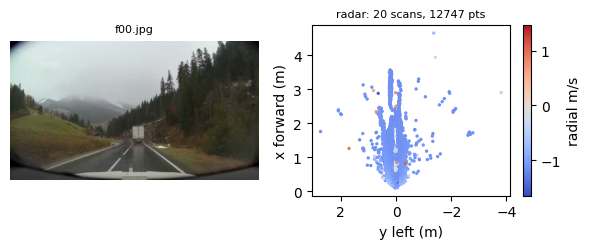

In [6]:
import matplotlib.pyplot as plt
from PIL import Image

d = os.path.join(EX, r["raw"])
paths = sorted(glob.glob(os.path.join(d, "frames", "*.jpg")))
z = np.load(os.path.join(d, "radar.npz"))
pts, ch = z["points"].astype(np.float32), [str(c) for c in z["channels"]]
print(f"프레임 {len(paths)}장 · 반사점 {len(pts)}개 · 채널 {ch}")

fig, axes = plt.subplots(1, len(paths) + 1, figsize=(3.1 * (len(paths) + 1), 2.6))
axes = np.atleast_1d(axes)
for ax, p in zip(axes, paths):
    ax.imshow(Image.open(p)); ax.set_title(os.path.basename(p), fontsize=8)
    ax.axis("off")
ax = axes[-1]
# 그림 안 글자는 ASCII 로 둔다. matplotlib 의 기본 폰트에 한글 글리프가 없어
# 라벨이 네모로 나오고, 폰트 등록을 요구하면 노트북이 기계를 가린다.
if len(pts):
    s = ax.scatter(pts[:, ch.index("y")], pts[:, ch.index("x")], s=2,
                   c=pts[:, ch.index("radial_velocity")], cmap="coolwarm")
    ax.set_title(f"radar: {r['radar_scans']} scans, {len(pts)} pts", fontsize=8)
    ax.invert_xaxis(); fig.colorbar(s, ax=ax, label="radial m/s")
else:
    ax.text(0.5, 0.5, "no returns", ha="center", va="center")
    ax.set_title("clip has no forward radar", fontsize=8)
ax.set_xlabel("y left (m)"); ax.set_ylabel("x forward (m)")
plt.tight_layout(); plt.show()

## 5. 빌드된 파일의 실제 아이템

여기서부터는 parquet 이 있는 기계에서만 돕니다. 위의 예제가 빌드 전체와 같은 규칙으로 만들어졌는지 확인하는 절입니다.

In [7]:
built = pd.read_parquet(ITEMS)
for v in VARIANTS:
    sub = built[built.task == v]
    if sub.empty:
        print(f"{v}: 파일에 없음"); continue
    r = sub.iloc[0]
    print("=" * 96)
    print(f"{v}   clip {r.clip_id[:8]}  frame {r.frame} (t={r.frame-1}s)  split {r.split}")
    print("Q:"); print(wrap(r.prompt))
    print("A:"); print(wrap(r.target))

det_objects_azdeg   clip 1f47bf7f  frame 4 (t=3s)  split train
Q:
   List every road user in the forward sector with its class, range and azimuth.
A:
   automobile 5 m az -57 deg; automobile 16 m az -53 deg; automobile 18 m az +31 deg;
   automobile 21 m az -23 deg; automobile 28 m az -33 deg; automobile 31 m az -31 deg;
   automobile 41 m az -28 deg; automobile 50 m az -17 deg
det_objects_3dbbox   clip 1f47bf7f  frame 4 (t=3s)  split train
Q:
   List every road user in the forward sector with its class and 3D position as (x, y, z) in
   metres, x forward, y left, z up.
A:
   automobile (3.0, -4.6, 0.6); automobile (9.7, -13.0, 0.9); automobile (15.7, 9.6, 1.2);
   automobile (19.7, -8.2, 0.5); automobile (23.5, -15.5, 0.8); automobile (26.7, -15.8, 0.4);
   automobile (36.4, -19.6, 0.4); automobile (48.2, -14.6, -0.1)


## 6. CoT — 근거가 답을 만드는가

`_cot` 변형은 `{"rationale": ..., "answer": ...}` 입니다. **근거를 따라가면 답이 나와야** 합니다. 나오지 않으면 그 사슬은 잘못된 것이고, 보상을 걸면 모델이 그 잘못된 사슬을 배웁니다.

In [8]:
for v in VARIANTS:
    name = v + "_cot"
    sub = built[built.task == name] if 'built' in dir() else None
    if sub is None or sub.empty:
        continue
    r = sub.iloc[0]
    d = json.loads(r.target)
    print("=" * 96); print(name)
    print("R:"); print(wrap(d["rationale"]))
    print("A:"); print(wrap(d["answer"]))

det_objects_azdeg_cot
R:
   automobile: camera az -54 deg, no radar return; automobile: camera az -54 deg, radar 1
   return at 16 m az -45 deg; automobile: camera az +34 deg, radar 3 returns at 18 m az +26
   deg; automobile: camera az -25 deg, radar 1 return at 20 m az -22 deg; automobile: camera
   az -35 deg, radar 2 returns at 28 m az -34 deg; automobile: camera az -32 deg, no radar
   return; automobile: camera az -30 deg, no radar return; automobile: camera az -17 deg,
   radar 1 return at 49 m az -17 deg. Range comes from the radar where it has a return and
   from the camera alone where it does not.
A:
   automobile 5 m az -57 deg; automobile 16 m az -53 deg; automobile 18 m az +31 deg;
   automobile 21 m az -23 deg; automobile 28 m az -33 deg; automobile 31 m az -31 deg;
   automobile 41 m az -28 deg; automobile 50 m az -17 deg
det_objects_3dbbox_cot
R:
   automobile: camera az -54 deg, no radar return; automobile: camera az -54 deg, radar 1
   return at 16 m az -45 deg; auto

## 7. 보상

평가 채점기에서 유도했습니다. 정답을 그대로 넣으면 1.0 이 나와야 하고, 내용을 망가뜨리면 떨어져야 합니다.

In [9]:
import re
from training.task_scorers import reward_for

def wreck(text):
    """형식은 두고 숫자만 2배로."""
    return re.sub(r"\d+(?:\.\d+)?",
                  lambda m: str(round(float(m.group()) * 2, 1)), text)

rows = []
for v in VARIANTS:
    for name in (v, v + "_cot"):
        fn = reward_for(name)
        if fn is None:
            continue
        sub = built[built.task == name] if 'built' in dir() else None
        if sub is None or sub.empty:
            continue
        t = sub.iloc[0].target
        rows.append({"task": name, "reward": fn.__name__,
                     "정답": round(fn(t, t), 3),
                     "숫자 2배": round(fn(wreck(t), t), 3)})
pd.DataFrame(rows)

,task,reward,정답,숫자 2배
0,det_objects_azdeg,reward_objects,1.0,0.00
1,det_objects_azdeg_cot,reward_with_rationale[det_objects_azdeg],1.0,0.15
2,det_objects_3dbbox,reward_objects,1.0,0.00
3,det_objects_3dbbox_cot,reward_with_rationale[det_objects_3dbbox],1.0,0.15


## 8. 데이터 양

`val` 은 `train` 에 합쳐져 있습니다 — 클립 분할이 train 86,607 / val 54,163 / test 37,121 인데, 모델 선택은 `test` 에서 하므로 검증용 3분의 1이 쓰이지 않고 있었습니다.

In [10]:
from collections import Counter
from training.instruct_data import load_items
names = [v for v in VARIANTS] + [v + "_cot" for v in VARIANTS]
rows = []
for split in ("train", "test"):
    c = Counter(i["task"] for i in load_items(tuple(names), split))
    for n in names:
        rows.append({"task": n, "split": split, "items": c.get(n, 0)})
pd.DataFrame(rows).pivot(index="task", columns="split", values="items")

split,test,train
task,,
det_objects_3dbbox,185496,755238
det_objects_3dbbox_cot,170495,694230
det_objects_azdeg,185496,755238
det_objects_azdeg_cot,170495,694230


## 9. 이 태스크에서 내린 결정과 근거

**이동 표기를 뺐다**

라벨의 moved 는 트랙 전체 20초 변위인데 입력은 1프레임 + 1초입니다. 레이더가 보는 물체만 놓고도 그 순간의 도플러와 85.8% 만 일치했고, 나머지는 입력으로 도달할 수 없는 정답이었습니다. 이동 판정은 06 이 맡습니다.

**상위 8개 절단**

앞에 물체가 12개 있어도 8개만 적히므로, 9번째를 맞혀도 오탐이 됩니다.

**오토라벨**

source='scene:obstacles:autolabels:v2'. 사람이 검증한 텍스트는 QA 뿐입니다.